In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts
from scipy.signal import find_peaks

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *



plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
channel="Channel 4"
data_dir = Path("/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/data/WA0089/voltage_sweep/260706")

# file_name = "WA0089_750V_525MHz_led100" 
# file_name = "WA0089_775V_525MHz_led100" 
# file_name = "WA0089_800V_525MHz_led100"  
file_name = "WA0089_825V_525MHz_led100" 
# file_name = "WA0089_850V_525MHz_led100"
# file_name = "WA0089_875V_525MHz_led100"
# file_name = "WA0089_900V_525MHz_led100"
# file_name = "WA0089_925V_525MHz_led100" 
# file_name = "WA0089_950V_525MHz_led100"
# file_name = "WA0089_975V_525MHz_led100" 
# file_name = "WA0089_1000V_525MHz_led100" 

# Set to a number for quick iteration, or None to use all matching files.
max_files = 2

files = find_pmt_files(data_dir, file_name, max_files=max_files)
for file in files:
    print(f'"{file}",')
print(f"Number of files loaded: {len(files)}")

# save
save_plots = False
save_dir = 'plots/260706'
file_nickname = file_name

fit_inputs = "fit_data"
fit_inputs_path = Path(fit_inputs)
fit_inputs_path.mkdir(parents=True, exist_ok=True)

"/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/data/WA0089/voltage_sweep/260706/WA0089_825V_525MHz_led100-1.h5",
"/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/data/WA0089/voltage_sweep/260706/WA0089_825V_525MHz_led100-10.h5",
Number of files loaded: 2


In [3]:
chunk_size = 512 # files are read in chunks, it speeds up things
baseline_window_ns                = (0, 20)

# Load files

1. read files
2. remove saturated events
3. subtract baseline
4. remove envents that peak in the baseline window


returns:
- time_ns: array of time in ns 
- waveforms_mW: array of voltages in mV (each roe corresponds to a waveform)
- df: pandas dataframe containing useful information such as, peak time, amplitude, charge...

In [4]:

time_ns, waveforms_mV, df =  load_files_one_go(files, chunk_size, baseline_window_ns, channel)

# save dataframe to file: it speeds up the fit greatly (from several minutes to seconds)
df.to_pickle(f"{fit_inputs}/{file_nickname}_df.pkl") 


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT_main/PMT-characterization/PMT_calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT_main/PMT-characterization/PMT_calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       60000      100.0%        100.0%
peaks in the baseline         59978      100.0%        100.0%


In [5]:
df.columns

Index(['peak_idx', 'peak_time_ns', 'peak_amplitude_mV', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'peak_width_ns', 'rise_time_10_90_ns',
       'fall_time_90_10_ns', 'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns',
       'cfd50_rise_ns', 'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns',
       'cfd30_fall_ns', 'cfd50_fall_ns', 'cfd90_fall_ns',
       'charge_cfd10_window_mV_ns', 'charge_cfd20_window_mV_ns',
       'charge_cfd30_window_mV_ns', 'charge_cfd50_window_mV_ns',
       'charge_cfd90_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'baseline_mean_mV',
       'baseline_rms_mV', 'baseline_slope_mV_per_ns', 'event_file',
       'event_segment', 'snr'],
      dtype='str')

# Some plots

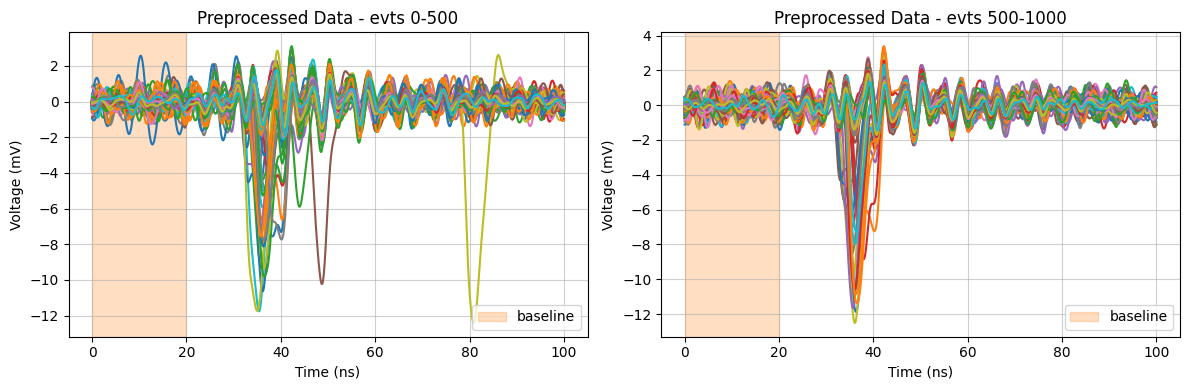

In [6]:
n_to_plot = 500

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_mV[:n_to_plot], title=f"Preprocessed Data - evts 0-{n_to_plot}")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_mV[n_to_plot:2*n_to_plot], title=f"Preprocessed Data - evts {n_to_plot}-{2*n_to_plot}")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout()
save_plot(fig, save_plots, save_dir, file_nickname,"few_waveforms", Nevents=n_to_plot);

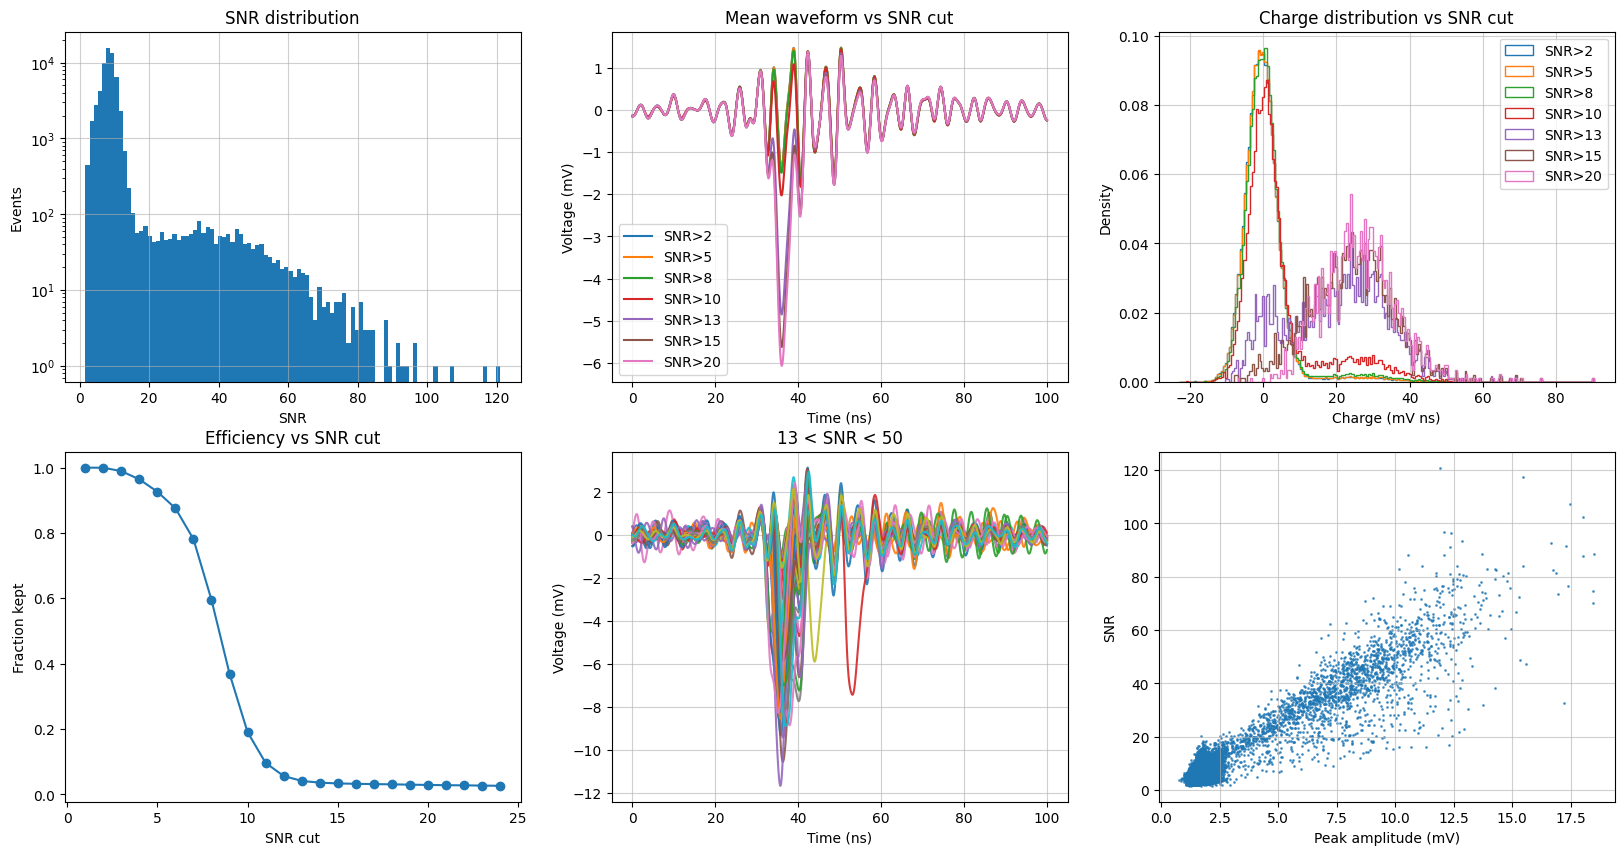

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()
plot_snr_distribution(axes[0], df)
plot_mean_waveforms_vs_snr(axes[1], df, waveforms_mV, time_ns, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_charge_histograms_vs_snr(axes[2], df, cuts=(2, 5, 8, 10, 13, 15, 20))
plot_snr_efficiency(axes[3], df, cuts=np.arange(1, 25))
plot_waveforms_in_snr_range( axes[4],  df, waveforms_mV, time_ns, snr_min=13, snr_max=50, n_waveforms=50)  
plot_snr_vs_amplitude(axes[5], df)  
save_plot(fig, save_plots, save_dir, file_nickname, f"snr_repport",  Nevents=None);

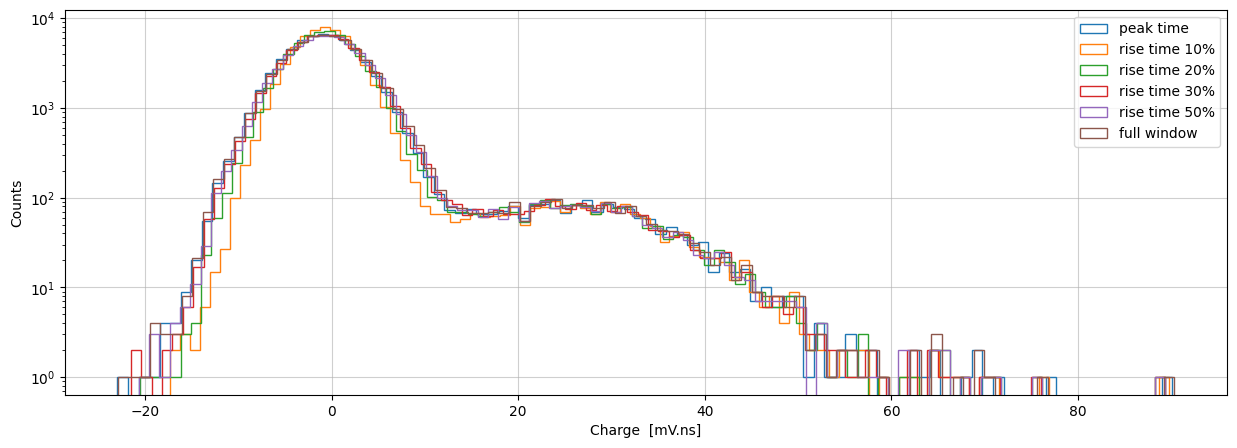

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))


rg = None #(-20, 10)
den=False

axes.hist(df.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.set_xlabel('Charge  [mV.ns]');
axes.set_ylabel('Counts');
axes.legend();

save_plot(fig, save_plots, save_dir, file_nickname, f"charge_all_methods",  Nevents=None);



# Baseline Study

In [9]:
from scipy import stats
from scipy.stats import norm
from scipy.stats import skew, kurtosis
from scipy.signal import correlate
from scipy.signal import welch

In [10]:
t, wfs, df = time_ns, waveforms_mV, df

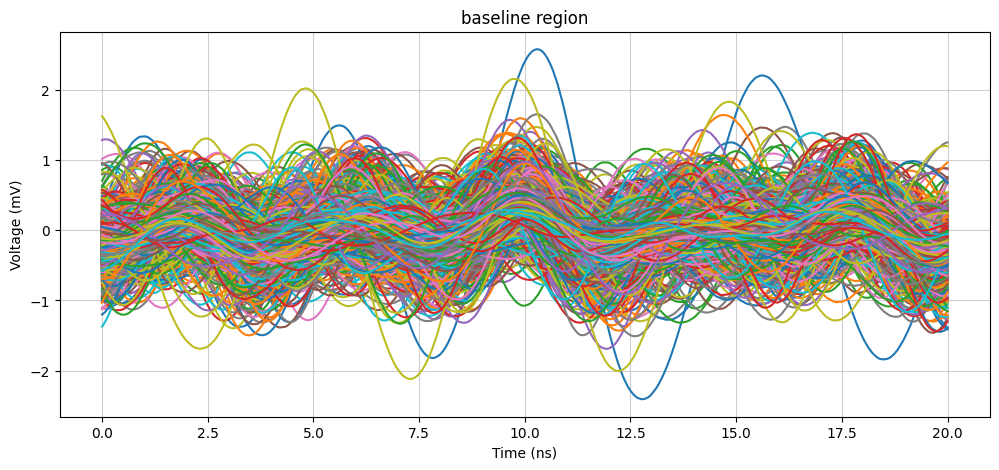

In [11]:
mask = (t >= baseline_window_ns[0]) & (t <= baseline_window_ns[1])
baseline_region = wfs[:, mask]
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
add_plot_waveforms(axes, t[mask], baseline_region[:5000], title='baseline region')
save_plot(fig, save_plots, save_dir, file_nickname, f"Baseline",  Nevents=5000);

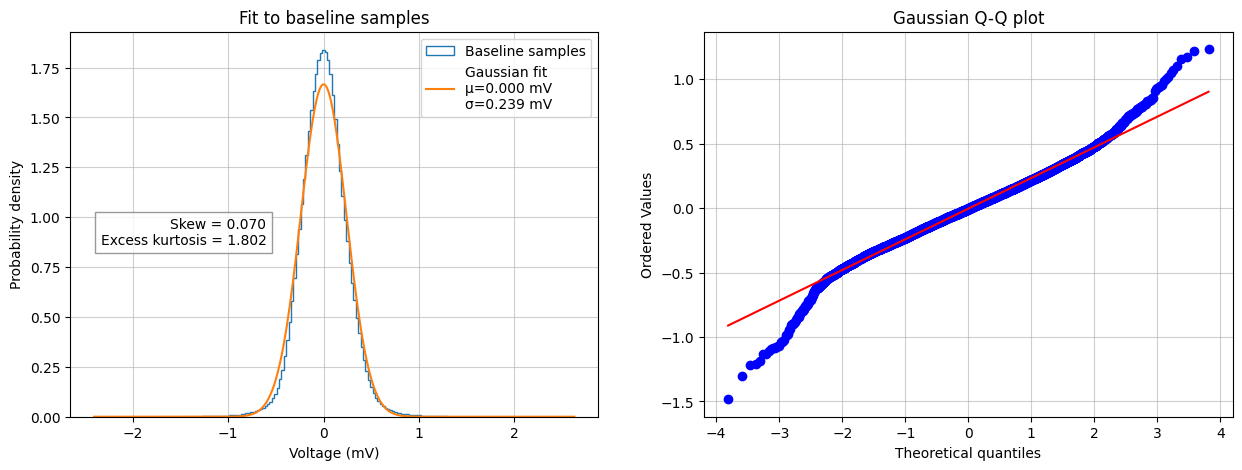

In [12]:
samples = baseline_region.ravel()
mu, sigma = norm.fit(samples)
sk = skew(samples)
kurt = kurtosis(samples)

stats_text = ( f"Skew = {sk:.3f}\n" f"Excess kurtosis = {kurt:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

x = np.linspace(samples.min(), samples.max(), 500)
axes[0].hist(samples, bins=200, density=True, histtype='step', label='Baseline samples')
axes[0].plot(x, norm.pdf(x, mu, sigma), label=f'Gaussian fit\nμ={mu:.3f} mV\nσ={sigma:.3f} mV')
axes[0].text( -0.6, 1.0, stats_text, ha='right', va='top',
          bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray') )
axes[0].set_xlabel("Voltage (mV)")
axes[0].set_ylabel("Probability density")
axes[0].set_title("Fit to baseline samples")
axes[0].legend();

rng = np.random.default_rng(42)
idx = rng.choice(len(samples), size=10_000, replace=False)
stats.probplot(samples[idx], dist="norm", plot=plt)
axes[1].set_title("Gaussian Q-Q plot")
save_plot(fig, save_plots, save_dir, file_nickname, f"baseline_fit",  Nevents=None);





Sampling step: 0.01562 ns


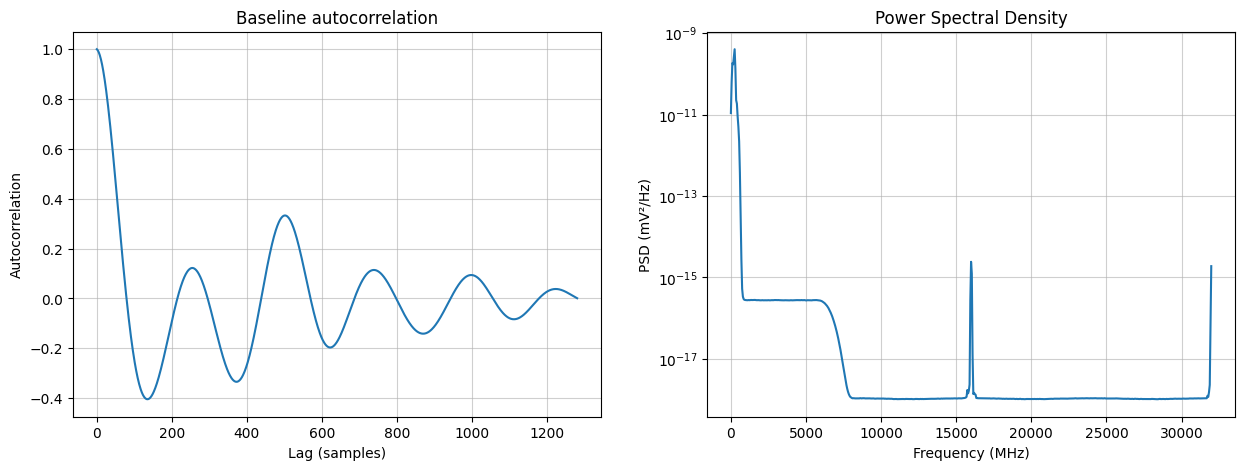

In [13]:
corr = np.zeros(baseline_region.shape[1])
for wf in baseline_region:
    c = correlate(wf, wf, mode='full')
    c = c[c.size//2:]
    corr += c / c[0]          # normalize
corr /= len(baseline_region)
lags = np.arange(len(corr))


dt = np.median(np.diff(t))
print(f"Sampling step: {dt:.5f} ns")
fs = 1 / (dt * 1e-9)          # sampling frequency (Hz)
psds = []
for wf in baseline_region:
    f, Pxx = welch( wf, fs=fs, nperseg=len(wf), detrend='constant')
    psds.append(Pxx)
psd = np.mean(psds, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.ravel()

axes[0].plot(lags, corr)
axes[0].set_title("Baseline autocorrelation")
axes[0].set_xlabel("Lag (samples)")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(True);

axes[1].semilogy(f/1e6, psd)
axes[1].set_title("Power Spectral Density")
axes[1].set_xlabel("Frequency (MHz)")
axes[1].set_ylabel("PSD (mV²/Hz)")
axes[1].grid(True)

save_plot(fig, save_plots, save_dir, file_nickname, f"autocorrelation",  Nevents=None);

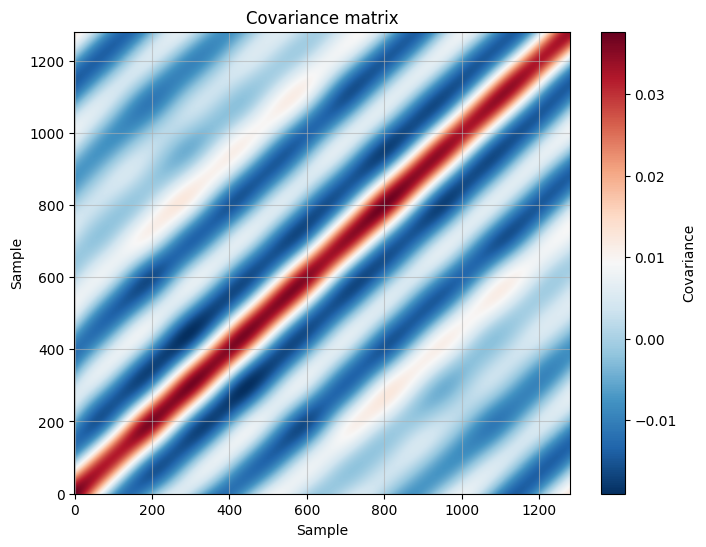

In [14]:
C = np.cov(baseline_region.T)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))

plt.imshow(C,
           origin='lower',
           cmap='RdBu_r',
           aspect='auto')
plt.colorbar(label="Covariance")
plt.title("Covariance matrix")
plt.xlabel("Sample")
plt.ylabel("Sample")

save_plot(fig, save_plots, save_dir, file_nickname, f"covariance_matrix",  Nevents=None);

# Further cuts?

In [15]:
df.columns

Index(['peak_idx', 'peak_time_ns', 'peak_amplitude_mV', 'area_mV_ns',
       'charge_peak_window_mV_ns', 'peak_width_ns', 'rise_time_10_90_ns',
       'fall_time_90_10_ns', 'cfd10_rise_ns', 'cfd20_rise_ns', 'cfd30_rise_ns',
       'cfd50_rise_ns', 'cfd90_rise_ns', 'cfd10_fall_ns', 'cfd20_fall_ns',
       'cfd30_fall_ns', 'cfd50_fall_ns', 'cfd90_fall_ns',
       'charge_cfd10_window_mV_ns', 'charge_cfd20_window_mV_ns',
       'charge_cfd30_window_mV_ns', 'charge_cfd50_window_mV_ns',
       'charge_cfd90_window_mV_ns', 'n_peaks', 'second_peak_time_ns',
       'second_peak_amplitude_mV', 'peak_separation_ns', 'baseline_mean_mV',
       'baseline_rms_mV', 'baseline_slope_mV_per_ns', 'event_file',
       'event_segment', 'snr'],
      dtype='str')

In [16]:
cutflow = CutFlow(len(df))
cutflow.apply( "peak amplitude > 5", df["peak_amplitude_mV"] > 5 )
cutflow.apply( "Single peak", df.n_peaks == 1 )
cutflow.print()

df_sel = df[cutflow.mask].copy()
waveforms_sel = waveforms_mV[cutflow.mask]

Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       59978      100.0%        100.0%
peak amplitude > 5             1689        2.8%          2.8%
Single peak                     631       37.4%          1.1%


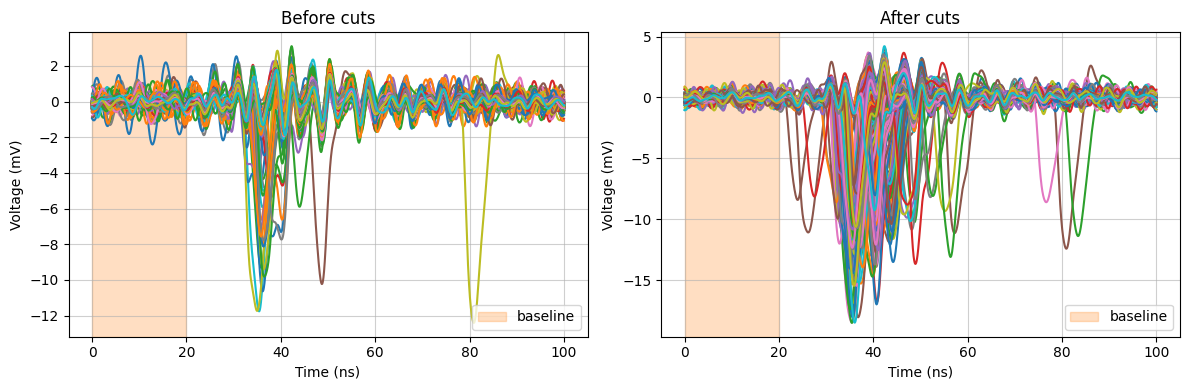

In [17]:
n_to_plot = 500

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

add_plot_waveforms(axes[0], time_ns, waveforms_mV[:n_to_plot], title=f"Before cuts")
axes[0].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[0].legend(loc="lower right")

add_plot_waveforms(axes[1], time_ns, waveforms_sel[:n_to_plot], title=f"After cuts")
axes[1].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
axes[1].legend(loc="lower right")

fig.tight_layout();
